In [45]:
import numpy as np
import matplotlib.pyplot as plt
import EFC_learningfMRI.globals as gl
import PcmPy as pcm
import pandas as pd
from scipy.stats import linregress
import os
import itertools
import seaborn as sb
import statsmodels.formula.api as smf
from EFC_learningfMRI.util import add_behav_pair_diff, ttest_im_sess
from EFC_learningfMRI.vis import plot_im_sess

In [53]:
H     = 'L'
atlas = 'ROI'
rois  = gl.rois[atlas]
glm   = 3
dist  = pd.read_csv(os.path.join(gl.baseDir, gl.pcmDir, f'dissimilarity.within_session.ROI.glm{glm}.tsv'), sep='\t')
dist  = dist[(dist.Hem==H) & (dist.chord.isin(['trained', 'untrained']))]
measX = ['ET', 'MD', 'force_abs', 'force_der', 'force_der_peak']
force = pd.read_csv(os.path.join(gl.baseDir, gl.behavDir, f'force.success.tsv'), sep='\t')
diff  = add_behav_pair_diff(dist, measures=measX, behav=force)

diff = diff[diff.sn!=117]

diff['crossnobis_res'] = np.nan
for sn in diff.sn.unique():
    m_sn  = diff.sn == sn
    d     = diff[m_sn]
    X     = np.c_[d[['MD', 'force_abs']].to_numpy(), np.ones(m_sn.sum())]
    y     = d['crossnobis'].to_numpy()
    diff.loc[m_sn, 'crossnobis_res'] = y - X @ (np.linalg.pinv(X) @ y)

diff_chord_sess = diff.groupby(['sn', 'Hem', 'roi', 'session', 'chord']).mean(numeric_only=True).reset_index()

hue_order = ['trained', 'untrained']
palette   = ['red', 'blue']

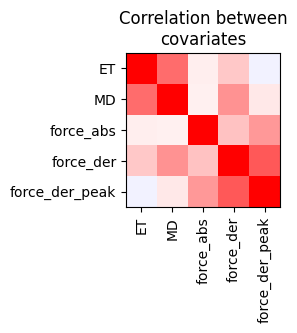

In [54]:
corrX = diff[measX].corr()

fig, ax = plt.subplots(figsize=(2, 2))

ax.imshow(corrX, vmin=-1, vmax=1, cmap='bwr')
ax.set_xticks(np.arange(len(measX)))
ax.set_yticks(np.arange(len(measX)))
ax.set_xticklabels(measX, rotation=90)
ax.set_yticklabels(measX)

ax.set_title('Correlation between\ncovariates')

plt.show()

           T  dof     p_val             CI95   roi  session
0  -0.807770   12  0.434944   [-0.023, 0.01]   SMA        3
3  -0.711697   12  0.490257  [-0.016, 0.008]   PMd        3
6  -1.637756   12  0.127409  [-0.042, 0.006]   PMv        3
9  -0.328970   12  0.747849  [-0.053, 0.039]    M1        3
12 -0.655218   12  0.524689   [-0.04, 0.021]    S1        3
15 -1.286294   12  0.222604  [-0.048, 0.012]  SPLa        3
18 -0.829943   12  0.422775   [-0.045, 0.02]  SPLp        3
7  -0.596775   12  0.561748  [-0.044, 0.025]   PMv        9
13  0.625035   12  0.543651   [-0.03, 0.054]    S1        9
10  0.485216   12  0.636261  [-0.039, 0.061]    M1        9
4  -0.923216   12  0.374086  [-0.037, 0.015]   PMd        9
1  -0.642256   12  0.532785  [-0.029, 0.016]   SMA        9
16 -0.475997   12  0.642625  [-0.035, 0.023]  SPLa        9
19 -0.320770   12  0.753902  [-0.036, 0.027]  SPLp        9
5   0.991544   12  0.340993  [-0.009, 0.024]   PMd       23
2   0.136153   12  0.893958  [-0.013, 0.

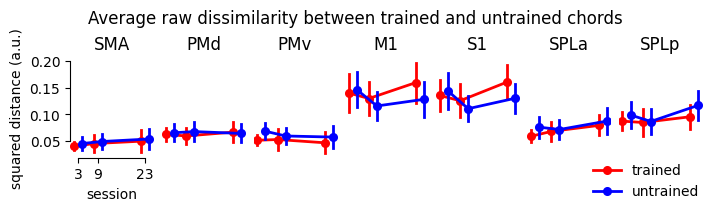

In [58]:
fig, axs = plt.subplots(1, len(rois), sharey=True, sharex=True, figsize=(7, 2), constrained_layout=True)

plot_im_sess(fig, axs, diff_chord_sess, rois, y='crossnobis', x='session', hue='chord', hue_order=hue_order, palette=palette, kind='point', estimator='mean', dodge=.4, add_zero=False)

sb.despine(ax=axs[0], trim=True)
axs[-1].legend([], frameon=False, loc='upper right')
fig.legend(frameon=False, loc='lower right',)
axs[0].set_xlabel('session')

axs[0].set_ylabel('squared distance (a.u.)')

fig.suptitle('Average raw dissimilarity between trained and untrained chords')

ttest = ttest_im_sess(diff_chord_sess, rois, y='crossnobis_res', x='session', hue='chord', hue_order=hue_order)
ttest['regionname'] = pd.Categorical(ttest.roi, categories=gl.rois[atlas], ordered=True)
ttest.sort_values(by='session', inplace=True)

print(ttest[['T', 'dof', 'p_val', 'CI95', 'roi', 'session']])

plt.show()

           T  dof     p_val             CI95   roi  session
0  -0.807770   12  0.434944   [-0.023, 0.01]   SMA        3
3  -0.711697   12  0.490257  [-0.016, 0.008]   PMd        3
6  -1.637756   12  0.127409  [-0.042, 0.006]   PMv        3
9  -0.328970   12  0.747849  [-0.053, 0.039]    M1        3
12 -0.655218   12  0.524689   [-0.04, 0.021]    S1        3
15 -1.286294   12  0.222604  [-0.048, 0.012]  SPLa        3
18 -0.829943   12  0.422775   [-0.045, 0.02]  SPLp        3
7  -0.596775   12  0.561748  [-0.044, 0.025]   PMv        9
13  0.625035   12  0.543651   [-0.03, 0.054]    S1        9
10  0.485216   12  0.636261  [-0.039, 0.061]    M1        9
4  -0.923216   12  0.374086  [-0.037, 0.015]   PMd        9
1  -0.642256   12  0.532785  [-0.029, 0.016]   SMA        9
16 -0.475997   12  0.642625  [-0.035, 0.023]  SPLa        9
19 -0.320770   12  0.753902  [-0.036, 0.027]  SPLp        9
5   0.991544   12  0.340993  [-0.009, 0.024]   PMd       23
2   0.136153   12  0.893958  [-0.013, 0.

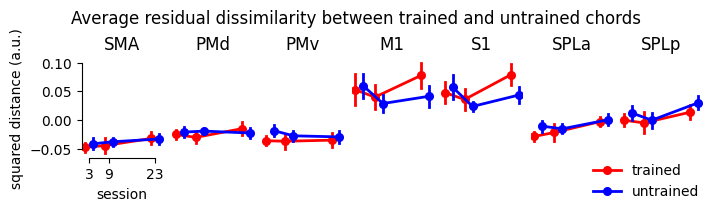

In [57]:
fig, axs = plt.subplots(1, len(rois), sharey=True, sharex=True, figsize=(7, 2), constrained_layout=True)

plot_im_sess(fig, axs, diff_chord_sess, rois, y='crossnobis_res', x='session', hue='chord', hue_order=hue_order, palette=palette, kind='point', estimator='mean', dodge=.4, add_zero=False)

sb.despine(ax=axs[0], trim=True)
axs[-1].legend([], frameon=False, loc='upper right')
fig.legend(frameon=False, loc='lower right',)
axs[0].set_xlabel('session')

axs[0].set_ylabel('squared distance (a.u.)')

fig.suptitle('Average residual dissimilarity between trained and untrained chords')

ttest = ttest_im_sess(diff_chord_sess, rois, y='crossnobis_res', x='session', hue='chord', hue_order=hue_order)
ttest['regionname'] = pd.Categorical(ttest.roi, categories=gl.rois[atlas], ordered=True)
ttest.sort_values(by='session', inplace=True)

print(ttest[['T', 'dof', 'p_val', 'CI95', 'roi', 'session']])

plt.show()